In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
## import of the datasets

from sklearn.datasets import make_circles

In [3]:
samples=1000
x,y=make_circles(samples,noise=0.03)

In [4]:
x,y

(array([[ 0.40011626, -0.68505988],
        [-0.58172045, -0.61098147],
        [-0.93552779, -0.29976097],
        ...,
        [-0.41383623, -0.91485543],
        [ 0.60650296,  0.81262357],
        [-0.10244439, -1.04395058]]),
 array([1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1,
        1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0,
        0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
        1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1,
        0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1,
        0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0,
        0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1,
        1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0,
        1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1,
        0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0,
        0, 0, 0, 0, 1, 1, 0, 

In [5]:
circles=pd.DataFrame({'x1':x[:,0],
                      'x2':x[:,1],
                      'label':y})

In [6]:
circles

,x1,x2,label
0,0.400116,-0.685060,1
1,-0.581720,-0.610981,1
2,-0.935528,-0.299761,0
3,0.782545,0.097806,1
4,0.741016,0.191142,1
...,...,...,...
995,0.854297,-0.506201,0
996,0.981821,0.020618,0
997,-0.413836,-0.914855,0
998,0.606503,0.812624,0


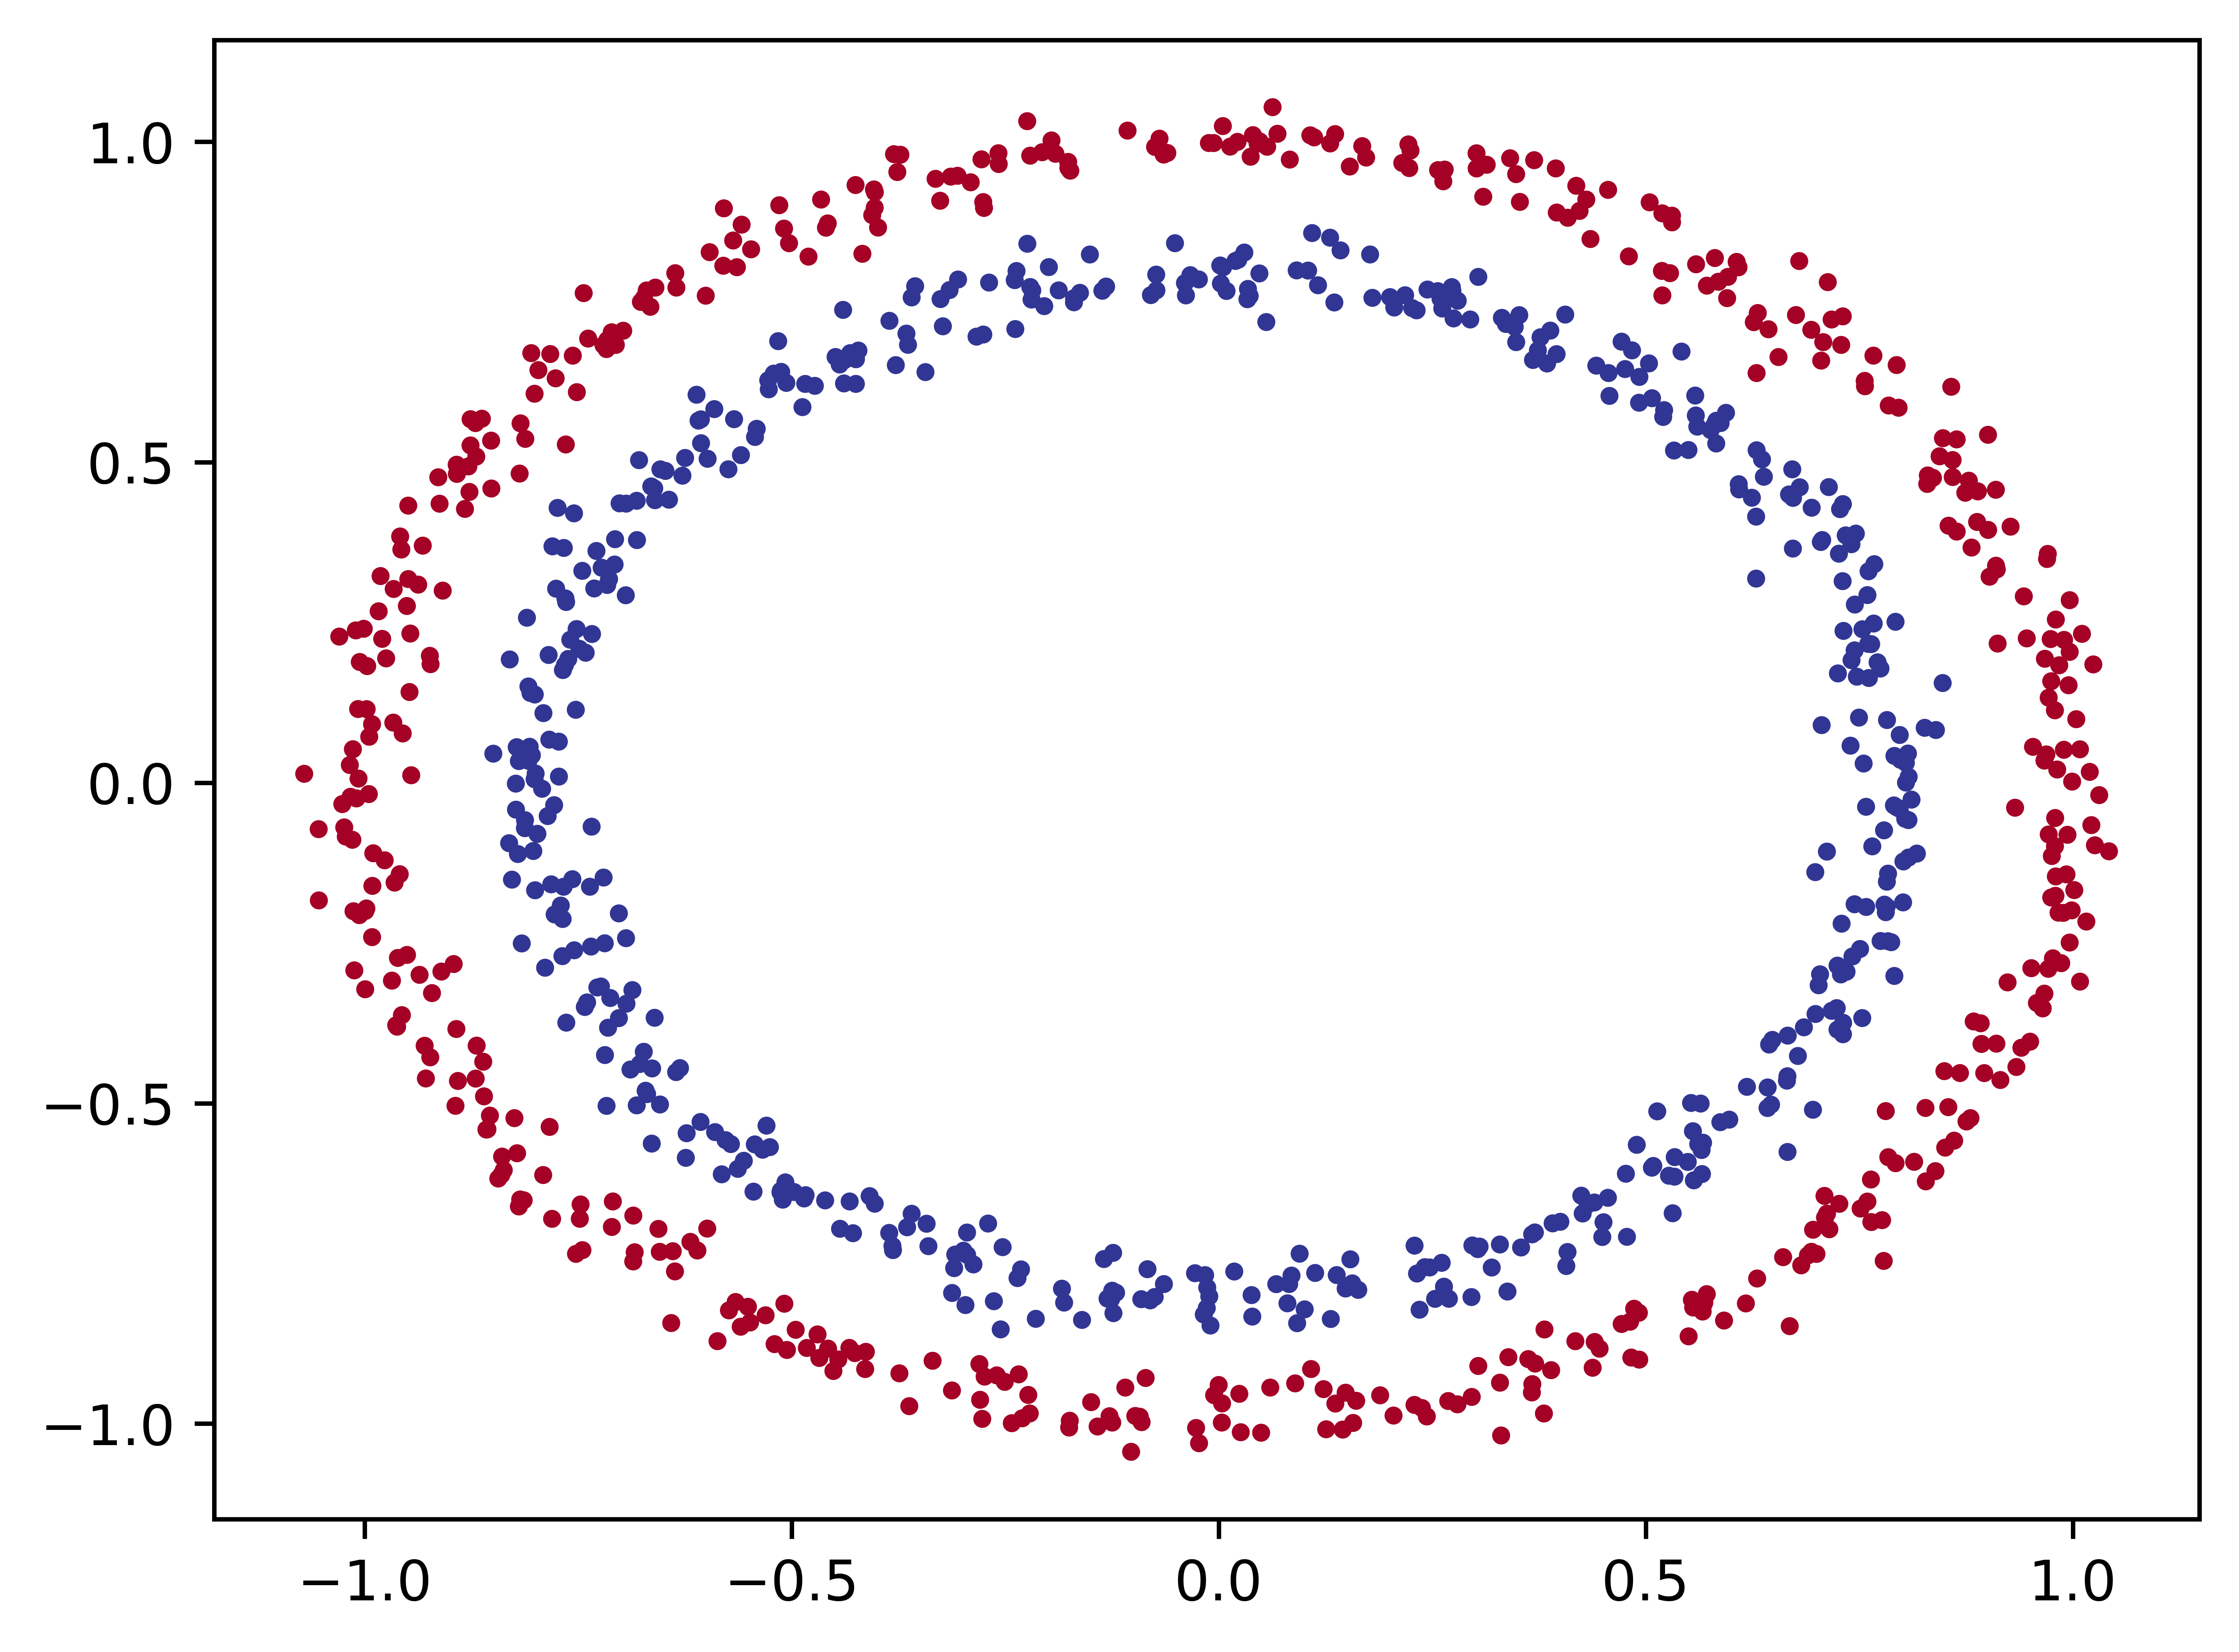

In [7]:
plt.figure(dpi=1000)
plt.scatter(circles['x1'],circles['x2'],c=y,cmap=plt.cm.RdYlBu,s=5)

In [8]:
device='mps' if torch.backends.mps.is_available() else 'cpu'
xt=torch.from_numpy(x).type(torch.float32)


In [9]:
xt
print(device)

mps


In [10]:
xt=xt.to(device)

In [11]:
xt

tensor([[ 0.4001, -0.6851],
        [-0.5817, -0.6110],
        [-0.9355, -0.2998],
        ...,
        [-0.4138, -0.9149],
        [ 0.6065,  0.8126],
        [-0.1024, -1.0440]], device='mps:0')

In [12]:
yt=torch.from_numpy(y).type(torch.float32).to(device)

In [13]:
yt

tensor([1., 1., 0., 1., 1., 1., 1., 1., 0., 1., 0., 1., 0., 1., 0., 1., 1., 0.,
        1., 0., 0., 1., 1., 1., 0., 1., 1., 1., 1., 0., 0., 0., 1., 0., 1., 1.,
        0., 1., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 1., 1., 0., 0., 1.,
        1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 1., 1., 0., 0., 1., 0.,
        0., 1., 0., 1., 0., 1., 0., 0., 0., 0., 1., 1., 0., 0., 0., 1., 0., 1.,
        0., 0., 1., 1., 1., 0., 0., 1., 0., 1., 0., 1., 1., 1., 0., 1., 0., 1.,
        0., 1., 0., 0., 0., 1., 1., 1., 1., 0., 0., 1., 0., 1., 0., 0., 1., 1.,
        0., 1., 0., 1., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 0., 0.,
        0., 1., 1., 0., 1., 1., 1., 0., 0., 1., 1., 0., 1., 1., 1., 1., 0., 1.,
        0., 0., 0., 1., 1., 1., 0., 0., 1., 0., 1., 0., 0., 0., 1., 0., 0., 1.,
        0., 1., 0., 0., 1., 1., 1., 1., 1., 1., 0., 0., 0., 1., 1., 1., 0., 1.,
        0., 0., 0., 0., 1., 0., 1., 0., 1., 0., 1., 1., 1., 1., 0., 0., 0., 1.,
        0., 1., 1., 0., 0., 0., 0., 0., 

In [14]:

x_train=xt[:int(0.8*len(xt))]
y_train=yt[:int(0.8*len(yt))]

In [15]:
x_train.shape,y_train.shape

(torch.Size([800, 2]), torch.Size([800]))

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
torch.manual_seed(42)
x_train,x_test,y_train,y_test=train_test_split(xt,yt,test_size=0.2)

In [18]:
x_train.shape

torch.Size([800, 2])

In [19]:
x_train.dtype

torch.float32

In [20]:
y_train.dtype

torch.float32

In [21]:
x_train.to(device)
x_test.to(device)
y_train.to(device)
y_test.to(device)


tensor([0., 1., 0., 1., 0., 1., 0., 0., 1., 1., 0., 0., 0., 1., 0., 1., 0., 1.,
        0., 0., 1., 0., 0., 0., 0., 1., 1., 1., 1., 0., 1., 1., 1., 0., 1., 0.,
        0., 1., 1., 0., 0., 0., 1., 0., 0., 1., 1., 1., 0., 0., 1., 0., 1., 0.,
        0., 1., 1., 0., 1., 0., 1., 1., 0., 1., 1., 0., 1., 0., 1., 0., 1., 0.,
        0., 1., 0., 0., 1., 0., 1., 1., 0., 0., 1., 0., 1., 1., 1., 1., 1., 1.,
        1., 0., 1., 1., 1., 0., 1., 0., 0., 1., 0., 0., 1., 1., 0., 1., 1., 0.,
        0., 1., 0., 1., 1., 0., 1., 0., 0., 0., 0., 1., 1., 1., 1., 0., 0., 1.,
        0., 0., 1., 0., 1., 1., 1., 1., 0., 0., 0., 1., 1., 1., 1., 1., 1., 0.,
        1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 1., 0., 1., 0.,
        0., 1., 1., 0., 0., 0., 1., 1., 0., 0., 0., 1., 1., 1., 0., 0., 0., 0.,
        1., 1., 1., 1., 1., 0., 1., 1., 0., 1., 1., 1., 0., 1., 1., 0., 1., 1.,
        0., 0.], device='mps:0')

In [22]:
x_train.device

device(type='mps', index=0)

In [23]:
class classification(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear1=nn.Linear(in_features=2,out_features=108),
        self.linear2=nn.Linear(in_features=108,out_features=1)

        self.two_layer=nn.Sequential(
                        nn.Linear(in_features=2,out_features=108),
                        nn.Linear(in_features=108,out_features=1)
        )

    def forward(self,x):
        return self.layer2(self.layer1(x))

In [24]:
model=classification()

In [25]:
model.to(device)


classification(
  (linear2): Linear(in_features=108, out_features=1, bias=True)
  (two_layer): Sequential(
    (0): Linear(in_features=2, out_features=108, bias=True)
    (1): Linear(in_features=108, out_features=1, bias=True)
  )
)

In [26]:
model.state_dict()

OrderedDict([('linear2.weight',
              tensor([[-0.0609, -0.0772, -0.0658, -0.0950, -0.0743, -0.0238,  0.0649,  0.0161,
                       -0.0732, -0.0772,  0.0479, -0.0716, -0.0118,  0.0462, -0.0445, -0.0105,
                       -0.0084, -0.0228, -0.0488, -0.0858, -0.0778, -0.0515,  0.0929, -0.0465,
                       -0.0646,  0.0233,  0.0265,  0.0527,  0.0731,  0.0536, -0.0954,  0.0085,
                        0.0583, -0.0089, -0.0567,  0.0917, -0.0360, -0.0548, -0.0868,  0.0043,
                        0.0426,  0.0213,  0.0190, -0.0730, -0.0899,  0.0017,  0.0877,  0.0555,
                       -0.0560, -0.0125, -0.0709, -0.0464,  0.0174,  0.0524,  0.0797, -0.0883,
                        0.0643, -0.0679,  0.0360,  0.0814,  0.0014,  0.0875, -0.0820, -0.0368,
                        0.0561, -0.0210, -0.0197, -0.0401,  0.0663,  0.0472,  0.0308, -0.0541,
                       -0.0781,  0.0104,  0.0285, -0.0444, -0.0269,  0.0650,  0.0077,  0.0043,
                  

In [27]:
### advanced way of model 

In [28]:
model=nn.Sequential(
                        nn.Linear(in_features=2,out_features=128),
                        nn.ReLU(),
                        nn.Linear(in_features=128,out_features=256),
                        nn.ReLU(),
                        nn.Linear(in_features=256,out_features=128),
                        nn.ReLU(),
                        nn.Linear(in_features=128,out_features=1)
).to(device)

In [29]:
list(model.parameters())

[Parameter containing:
 tensor([[ 5.4787e-01,  2.1365e-01],
         [ 4.4324e-02, -5.9479e-01],
         [-7.3401e-02,  6.7820e-01],
         [ 1.8007e-01,  6.0541e-02],
         [-1.4683e-01, -2.4663e-01],
         [ 4.2145e-01,  4.3606e-02],
         [ 4.6003e-01, -1.2516e-01],
         [ 3.0894e-01,  2.9187e-01],
         [ 1.1276e-01,  4.4433e-01],
         [ 4.4311e-01,  6.5543e-01],
         [ 5.4361e-01, -1.8080e-01],
         [-5.9865e-01,  1.2927e-01],
         [-6.1718e-03, -1.8443e-01],
         [-1.1841e-01,  3.3257e-02],
         [ 5.1593e-01,  2.2043e-01],
         [-2.5109e-01, -2.9078e-01],
         [-1.7510e-01, -2.7330e-01],
         [ 6.3585e-01,  3.7452e-01],
         [ 6.3850e-01,  2.2582e-03],
         [ 1.4260e-01,  2.4520e-01],
         [-6.6931e-01,  6.3142e-02],
         [-4.7298e-02, -3.9644e-01],
         [-5.4868e-01,  6.2598e-01],
         [ 5.7492e-01,  3.2772e-01],
         [ 6.7476e-01, -2.8695e-01],
         [-1.2213e-01,  2.6772e-01],
         [-1.16

In [30]:
pretrained=model(x_train)

In [31]:
pretrained

tensor([[ 5.1382e-03],
        [-7.1843e-03],
        [ 1.5051e-02],
        [ 5.4406e-03],
        [ 7.4466e-03],
        [-5.1330e-03],
        [ 1.3418e-02],
        [ 1.5110e-02],
        [ 7.5868e-03],
        [ 5.2331e-03],
        [-6.6127e-04],
        [-1.0349e-02],
        [-7.6874e-03],
        [ 4.7954e-03],
        [-1.3978e-03],
        [-3.4923e-03],
        [ 8.7746e-03],
        [-9.9934e-03],
        [ 2.9039e-03],
        [ 1.2930e-02],
        [ 8.5458e-03],
        [ 1.7405e-03],
        [-1.3433e-02],
        [-5.7093e-03],
        [-5.6054e-03],
        [ 3.5690e-03],
        [-7.2914e-04],
        [-2.7097e-03],
        [-1.2963e-02],
        [-4.7524e-03],
        [-1.0938e-02],
        [ 1.2292e-02],
        [-8.8571e-03],
        [ 1.5496e-02],
        [-6.8294e-03],
        [ 3.9429e-03],
        [-4.4099e-03],
        [ 5.5077e-03],
        [-6.0203e-03],
        [-1.0470e-02],
        [-6.2272e-03],
        [ 5.3272e-03],
        [-8.0411e-03],
        [ 1

In [32]:
### apply sigmoid function

torch.round(torch.sigmoid(pretrained))

tensor([[1.],
        [0.],
        [1.],
        [1.],
        [1.],
        [0.],
        [1.],
        [1.],
        [1.],
        [1.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [1.],
        [1.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [1.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [0.],
        [1.],
      

In [33]:
def accurate(predicted,test):
    
    correct=torch.eq(test,predicted).sum().item()
    print(correct)
    return (correct/len(test))*100

In [34]:
loss_fn=nn.BCEWithLogitsLoss()

In [35]:
optimizer=torch.optim.SGD(params=model.parameters(),lr=0.01)

In [36]:
def accuracy_fn(y_true,y_pred):
    correct=torch.eq(y_true,y_pred).sum().item()
    acc=(correct/len(y_pred))*100
    return acc

In [37]:
epochs=3000
lossval=[]
acu=[]
for epoch in range(epochs):

    model.train()
    y_pred=model(x_train).squeeze()
    loss=loss_fn(y_pred,y_train)
    lossval.append(loss.to('cpu'))
    print(loss)
    print(accuracy_fn(y_train,torch.round(torch.sigmoid(y_pred))))
    acu.append(accuracy_fn(y_train,torch.round(torch.sigmoid(y_pred))))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

tensor(0.6936, device='mps:0', grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
46.125
tensor(0.6936, device='mps:0', grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
47.125
tensor(0.6936, device='mps:0', grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
47.5
tensor(0.6935, device='mps:0', grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
47.625
tensor(0.6935, device='mps:0', grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
47.5
tensor(0.6935, device='mps:0', grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
47.75
tensor(0.6935, device='mps:0', grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
47.0
tensor(0.6935, device='mps:0', grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
46.75
tensor(0.6935, device='mps:0', grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
46.875
tensor(0.6934, device='mps:0', grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
46.625
tensor(0.6934, device='mps:0', grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
46.375
tensor(0.6934, device='mps:0', grad_fn=<BinaryCross

In [38]:
y_pred.shape

torch.Size([800])

In [39]:
with torch.inference_mode():
    y_logit=model(x_test)
    y_pred=torch.round(torch.sigmoid(y_logit))
y_pred

tensor([[0.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [0.],
        [0.],
        [1.],
        [1.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [0.],
        [0.],
        [1.],
        [0.],
        [0.],
        [0.],
        [0.],
        [1.],
        [1.],
        [1.],
        [1.],
        [0.],
        [1.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [0.],
        [1.],
        [1.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [0.],
        [1.],
        [1.],
        [1.],
        [0.],
        [0.],
        [1.],
        [0.],
        [1.],
        [0.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
      

In [40]:
accurate(y_pred,y_test)

20008


10004.0

In [41]:
len(y_test),len(y_pred)

(200, 200)

In [42]:
lossval=[i.detach().numpy() for i in lossval]

In [43]:
lossval

[array(0.69359136, dtype=float32),
 array(0.693574, dtype=float32),
 array(0.69355667, dtype=float32),
 array(0.69353926, dtype=float32),
 array(0.69352204, dtype=float32),
 array(0.6935047, dtype=float32),
 array(0.6934874, dtype=float32),
 array(0.69347006, dtype=float32),
 array(0.6934529, dtype=float32),
 array(0.69343567, dtype=float32),
 array(0.69341844, dtype=float32),
 array(0.6934011, dtype=float32),
 array(0.69338393, dtype=float32),
 array(0.6933668, dtype=float32),
 array(0.6933496, dtype=float32),
 array(0.6933323, dtype=float32),
 array(0.69331497, dtype=float32),
 array(0.69329745, dtype=float32),
 array(0.69328004, dtype=float32),
 array(0.6932627, dtype=float32),
 array(0.6932455, dtype=float32),
 array(0.69322824, dtype=float32),
 array(0.6932111, dtype=float32),
 array(0.6931938, dtype=float32),
 array(0.69317645, dtype=float32),
 array(0.69315886, dtype=float32),
 array(0.69314134, dtype=float32),
 array(0.6931236, dtype=float32),
 array(0.6931057, dtype=float32),


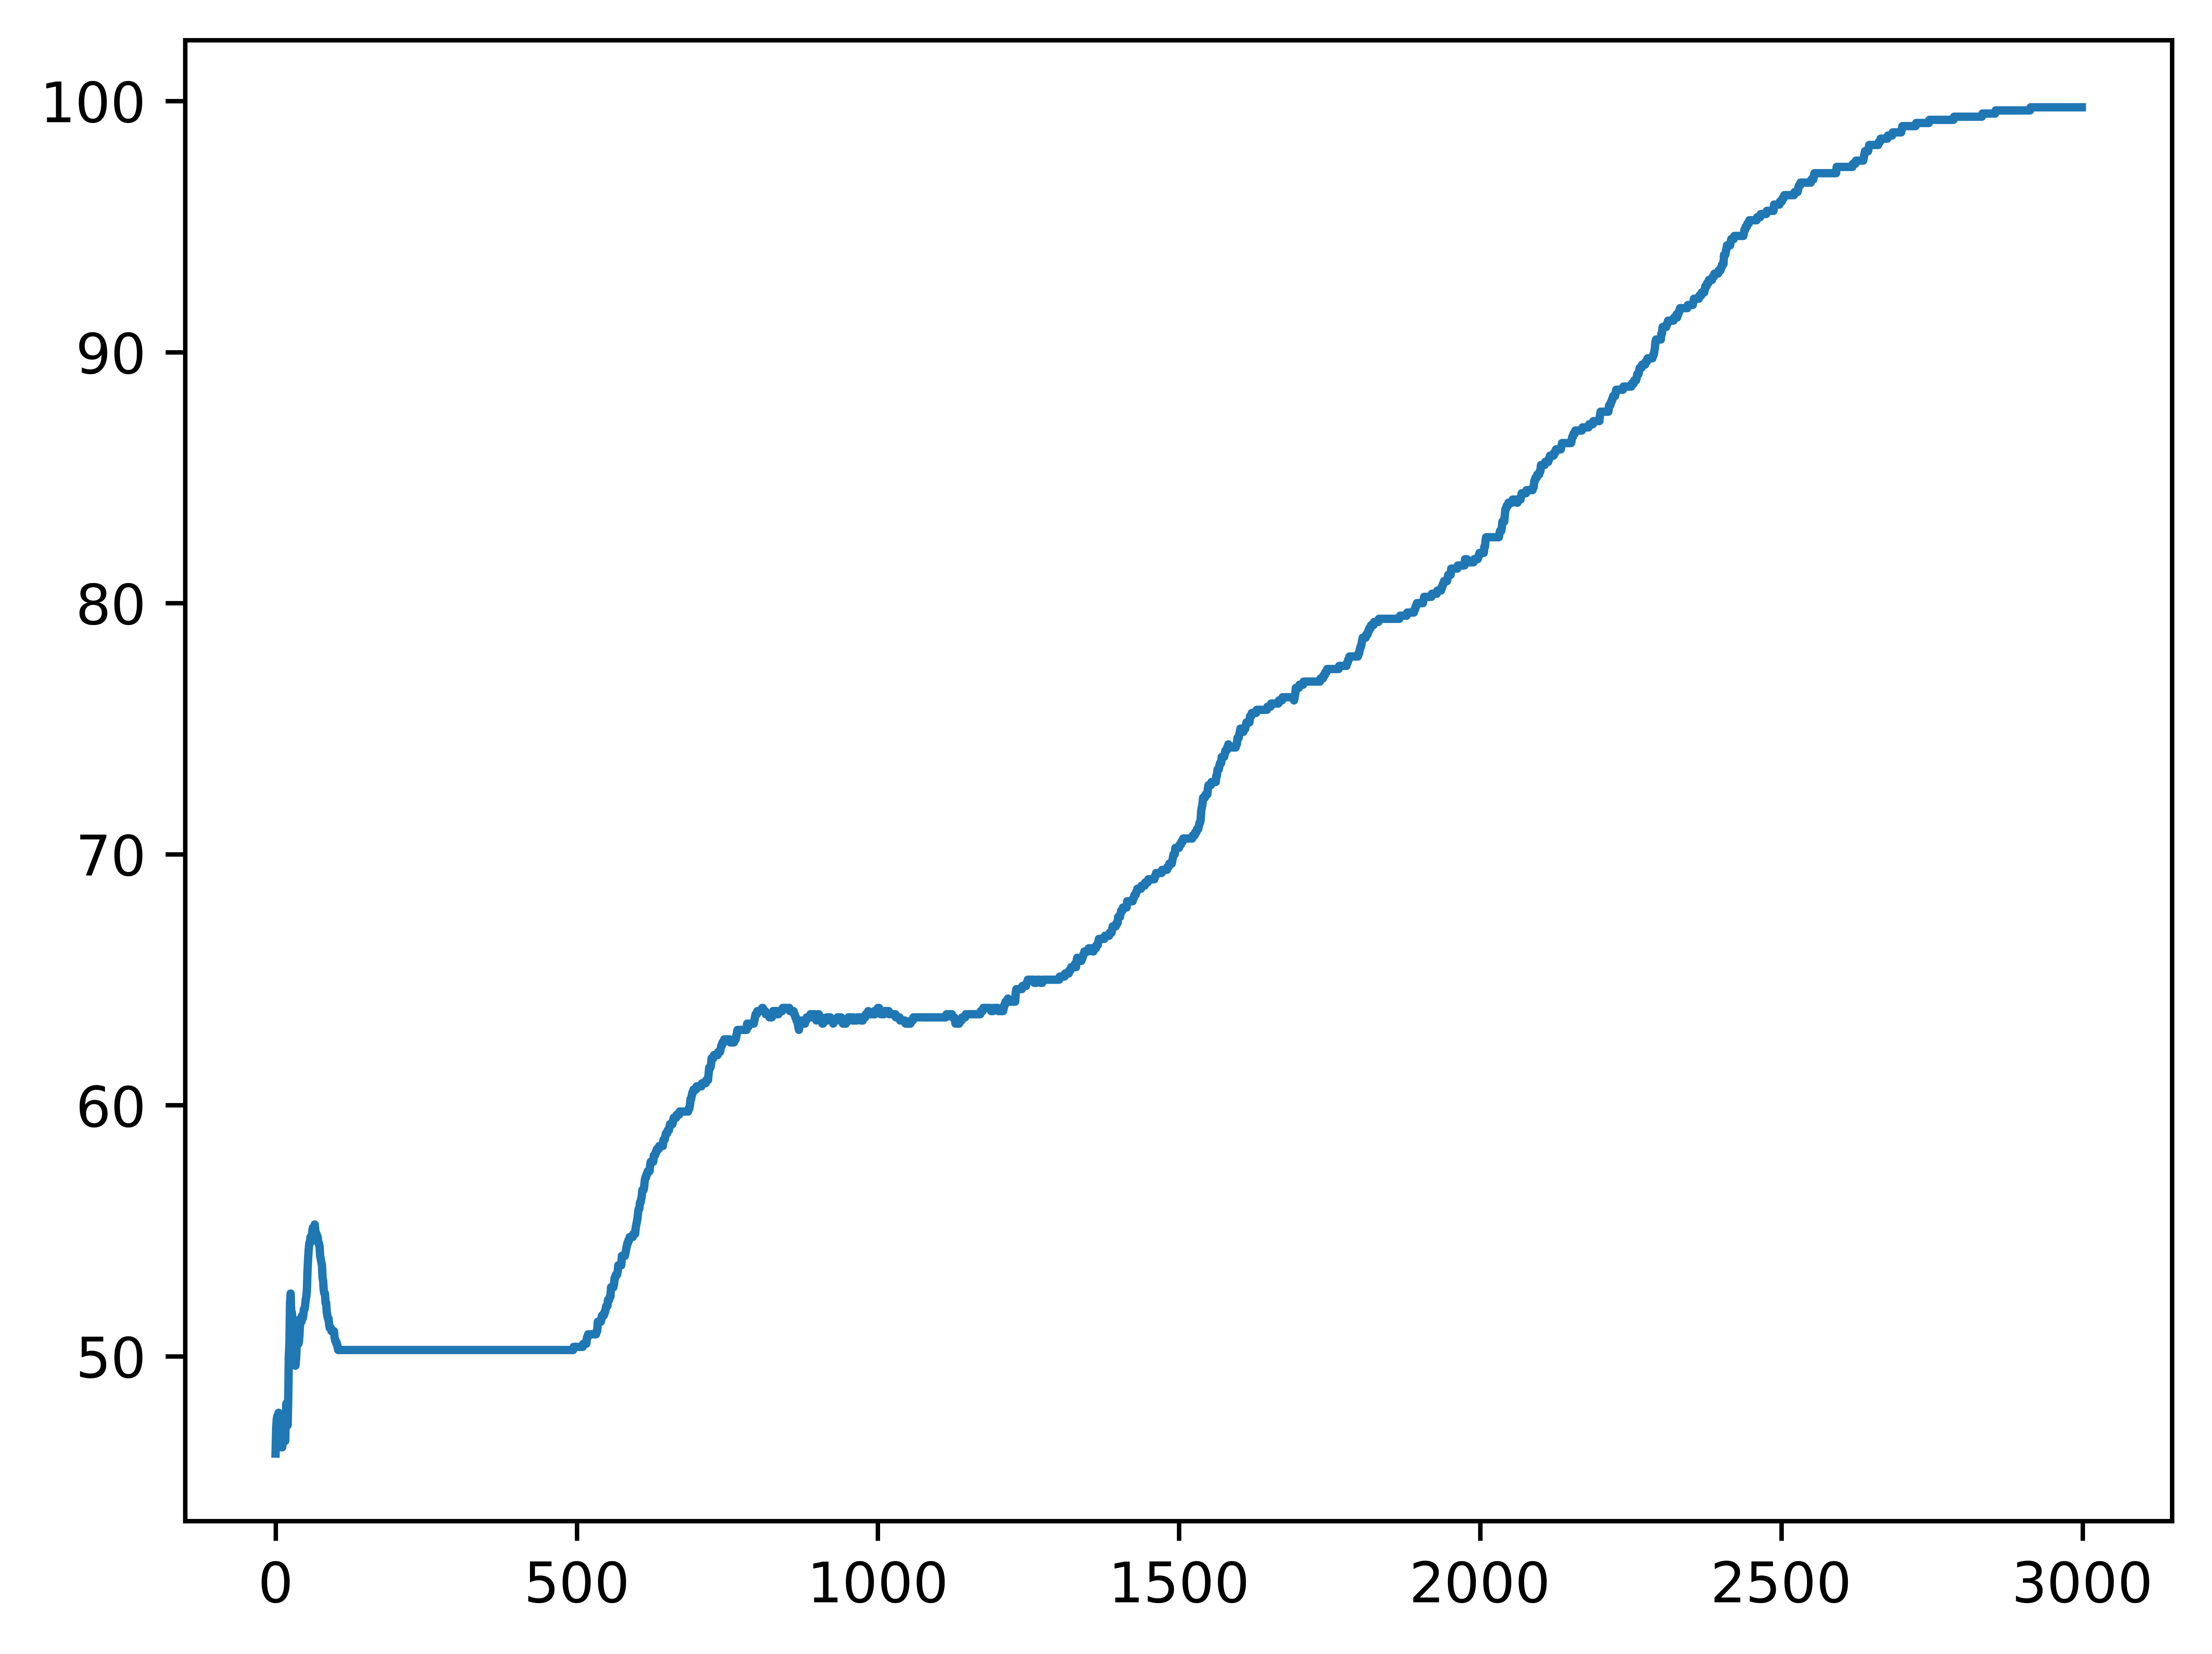

In [44]:
plt.figure(dpi=1000)
plt.plot(acu)
plt.savefig('classificatin_

In [45]:
acu[-1]

99.75